# 03 · 소성가공 예지보전 데이터 탐색

## EDA 계획

1. 정상·이상 파일의 규모, 센서, 상태값, 결측·중복을 확인합니다.
2. 수집 기간과 측정 간격을 조사하고 불연속 지점에서 연속 구간을 나눕니다.
3. 상태별 센서 분포·상관관계 및 대표 연속 구간의 파형을 비교합니다.
4. 구간을 넘지 않는 1초 RMS 특징으로 상태 차이를 살펴봅니다.
5. 이상 탐지와 고장 예측의 차이 및 날짜/구간 단위 검증 한계를 정리합니다.


원본 데이터는 수정하지 않습니다. 위에서부터 실행하세요. 프로젝트 `.venv` 커널과 `notebooks/requirements.txt`의 패키지를 사용합니다. 수치와 도표는 전체 데이터를 기준으로 하며 표본·표시 범위를 제한하면 해당 셀에 명시합니다. 탐색 결과는 모델 성능이나 인과 효과를 의미하지 않습니다.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from IPython.display import display
SEED = 42
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'data').is_dir())
pd.set_option('display.max_columns', 30)
fonts = {f.name for f in font_manager.fontManager.ttflist}
plt.rcParams['font.family'] = [next((f for f in ['Malgun Gothic','AppleGothic','NanumGothic'] if f in fonts), 'DejaVu Sans'), 'DejaVu Sans']
plt.rcParams.update({'axes.unicode_minus':False, 'figure.dpi':110, 'axes.spines.top':False, 'axes.spines.right':False})

def quality(df, exclude=()):
    x = df.drop(columns=list(exclude), errors='ignore')
    out = pd.DataFrame({'dtype':x.dtypes.astype(str), 'missing':x.isna().sum(),
                        'missing_pct':x.isna().mean()*100, 'unique':x.nunique()})
    print(f'행 {len(df):,} / 열 {len(df.columns)} / 제외 열을 뺀 중복 {x.duplicated().sum():,}')
    display(out)
    return out

def corr_plot(df, cols, title):
    corr = df[cols].corr(method='spearman')
    fig, ax = plt.subplots(figsize=(max(7,len(cols)*.65), max(5,len(cols)*.6)))
    im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
    ax.set_xticks(range(len(cols)),cols,rotation=70,ha='right')
    ax.set_yticks(range(len(cols)),cols); ax.set_title(title)
    fig.colorbar(im, ax=ax); plt.tight_layout(); plt.show()

def hist_grid(df, cols, title):
    fig, axes = plt.subplots(int(np.ceil(len(cols)/3)),3,figsize=(15,3.4*int(np.ceil(len(cols)/3))),squeeze=False)
    for ax,c in zip(axes.flat,cols):
        ax.hist(df[c].replace([np.inf,-np.inf],np.nan).dropna(),bins=40,color='#2563eb',alpha=.8)
        ax.set_title(c,fontsize=10); ax.set_ylabel('행 수')
    for ax in list(axes.flat)[len(cols):]: ax.set_visible(False)
    fig.suptitle(title); plt.tight_layout(); plt.show()

DATA = next((ROOT / 'data').glob('3.*'))

## 1. 파일·상태·품질 확인
파일명 normal/outlier와 상태 코드의 대응을 직접 확인합니다. 센서 단위는 추가 설명이 없어 원래 열 이름과 저장값을 사용합니다.

outlier_data
행 600 / 열 6 / 제외 열을 뺀 중복 0


,dtype,missing,missing_pct,unique
TimeStamp,str,0,0.0,600
AI0_Vibration,float64,0,0.0,594
AI1_Vibration,float64,0,0.0,597
AI2_Current,float64,0,0.0,340
Equipment_state,int64,0,0.0,1


press_data_normal
행 20,000 / 열 6 / 제외 열을 뺀 중복 1


,dtype,missing,missing_pct,unique
TimeStamp,str,0,0.0,19999
AI0_Vibration,float64,0,0.0,19124
AI1_Vibration,float64,0,0.0,19460
AI2_Current,float64,0,0.0,19934
Equipment_state,int64,0,0.0,1


Equipment_state,0,1
source,,
outlier_data,0,600
press_data_normal,20000,0


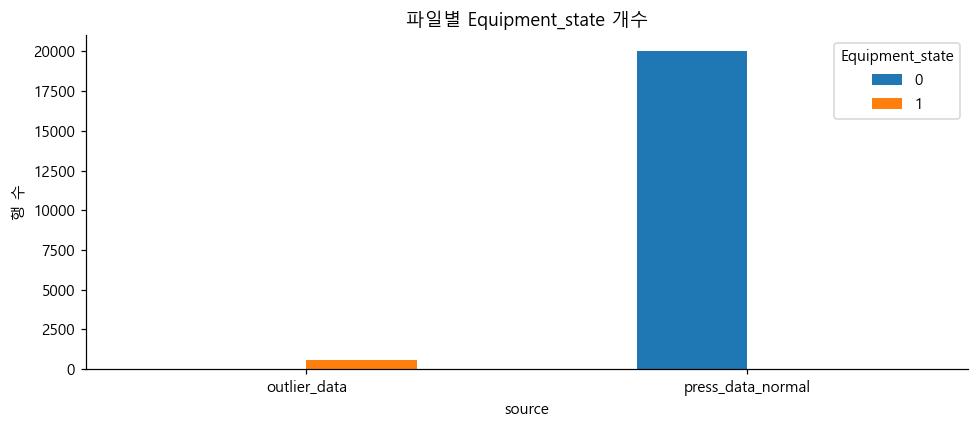

AI0_Vibration                                          \
                           mean       std       min    median       max   
source                                                                    
outlier_data           0.007578  0.447928 -1.502735  0.015771  1.803204   
press_data_normal     -0.000094  0.070634 -0.314570 -0.000171  0.351699   

                  AI1_Vibration                                          \
                           mean       std       min    median       max   
source                                                                    
outlier_data          -0.008137  0.241226 -0.751253  0.002161  0.509321   
press_data_normal     -0.000093  0.118888 -0.366498 -0.009317  0.399782   

                  AI2_Current                                               
                         mean         std        min     median        max  
source                                                                      
outlier_data        57.329741  153.172619 -399.35117  53.644187  538.82605  
press_data_normal    1.446209  122.664494 -271.56833   1.849830  273.23500

In [2]:
frames={p.stem:pd.read_csv(p) for p in sorted(DATA.rglob('*.csv'))}
sensors=['AI0_Vibration','AI1_Vibration','AI2_Current']
for name,df in frames.items():
    print(name);quality(df,['Unnamed: 0'])
    df['time']=pd.to_datetime(df['TimeStamp'],errors='coerce')
    df['source']=name
all_data=pd.concat(frames.values(),ignore_index=True)
counts=pd.crosstab(all_data.source,all_data.Equipment_state)
display(counts)
fig,ax=plt.subplots(figsize=(9,4));counts.plot.bar(ax=ax,rot=0,title='파일별 Equipment_state 개수');ax.set_ylabel('행 수');plt.tight_layout();plt.show()
display(all_data.groupby('source')[sensors].agg(['mean','std','min','median','max']))

## 2. 측정 간격과 연속 구간
원본 순서에서 0.1초 간격인 행만 같은 구간으로 묶습니다(허용 오차 0.002초). 중복·역순 시각, 결측 시각, 공백은 구간 경계입니다. 파일 전체를 일정 주파수의 한 파형으로 연결하지 않습니다.

,source,start,end,bad_time,duplicate_time,reverse_steps,gaps_over_0.102s,segments,median_step_s
0,outlier_data,2022-07-17 10:51:07.943,2022-07-17 10:53:53.540,0,0,0,20,21,0.1
1,press_data_normal,2022-07-12 00:00:00.019,2022-07-12 01:16:55.828,0,1,0,598,600,0.1


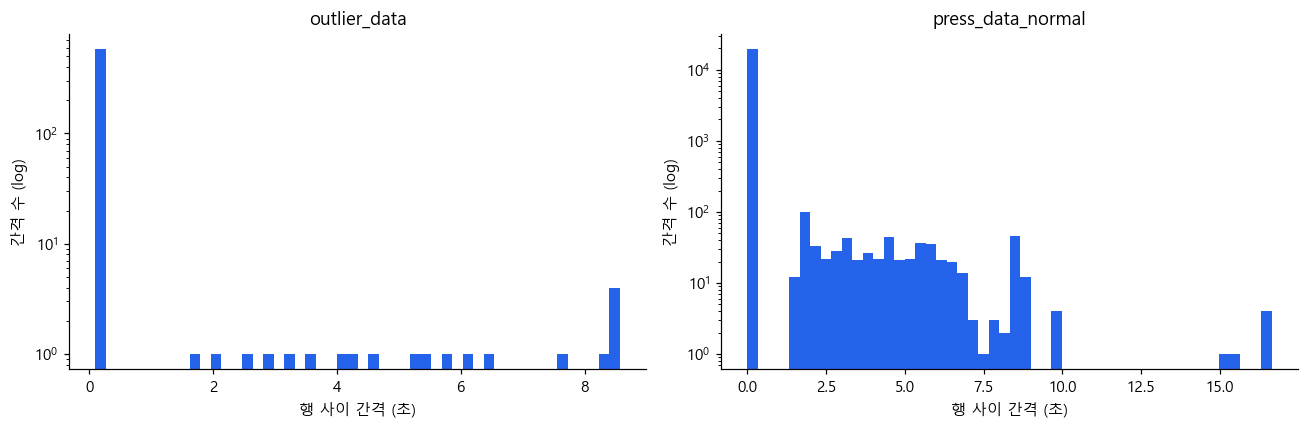

,count,mean,std,min,25%,50%,75%,max
source,,,,,,,,
outlier_data,21.0,28.571429,17.537307,3.0,15.0,28.0,47.0,50.0
press_data_normal,600.0,33.333333,16.425038,1.0,20.0,37.0,50.0,50.0


In [3]:
time_audit=[]; segmented=[]
fig,axes=plt.subplots(1,2,figsize=(12,4))
for ax,(name,df) in zip(axes,frames.items()):
    dt=df.time.diff().dt.total_seconds()
    regular=np.isclose(dt,.1,atol=.002,rtol=0)
    df['segment']=(~regular).cumsum()
    segmented.append(df)
    time_audit.append({'source':name,'start':df.time.min(),'end':df.time.max(),'bad_time':df.time.isna().sum(),
                       'duplicate_time':df.time.duplicated().sum(),'reverse_steps':dt.lt(0).sum(),
                       'gaps_over_0.102s':dt.gt(.102).sum(),'segments':df.segment.nunique(),'median_step_s':dt.median()})
    ax.hist(dt.dropna(),bins=50,color='#2563eb');ax.set_yscale('log');ax.set_title(name);ax.set(xlabel='행 사이 간격 (초)',ylabel='간격 수 (log)')
display(pd.DataFrame(time_audit));plt.tight_layout();plt.show()
all_data=pd.concat(segmented,ignore_index=True)
lengths=all_data.groupby(['source','segment']).size().rename('rows')
display(lengths.groupby(level=0).describe())

## 3. 상태별 분포와 파형
대표 파형은 파일별 가장 긴 연속 구간의 처음 100개 행(최대 약 10초)입니다. 임의로 떨어진 구간을 선으로 잇지 않습니다.

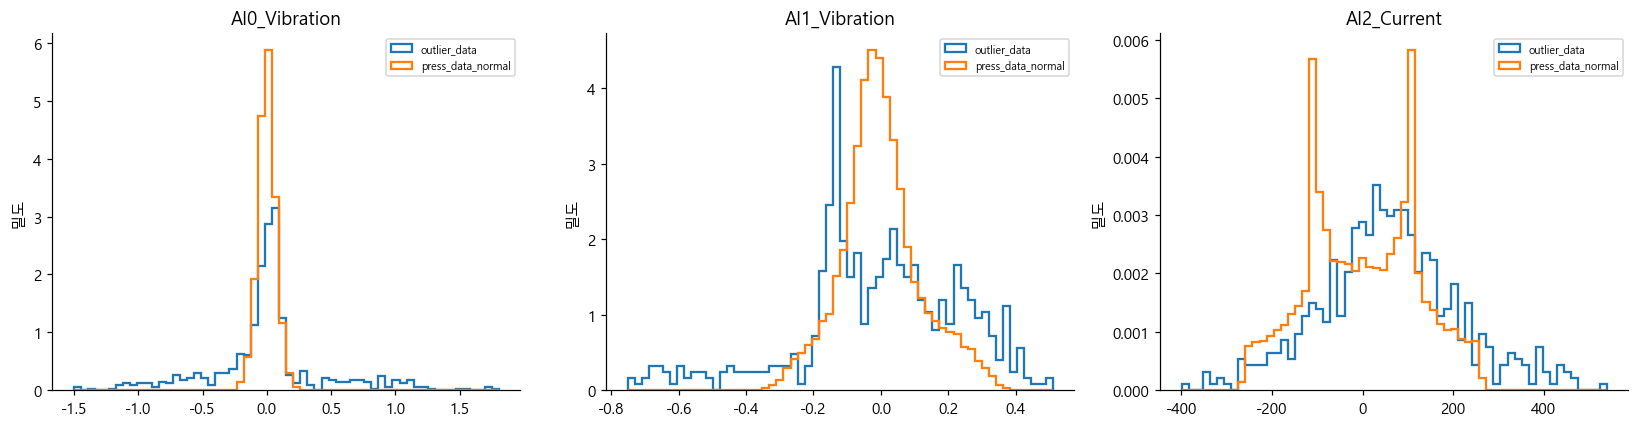

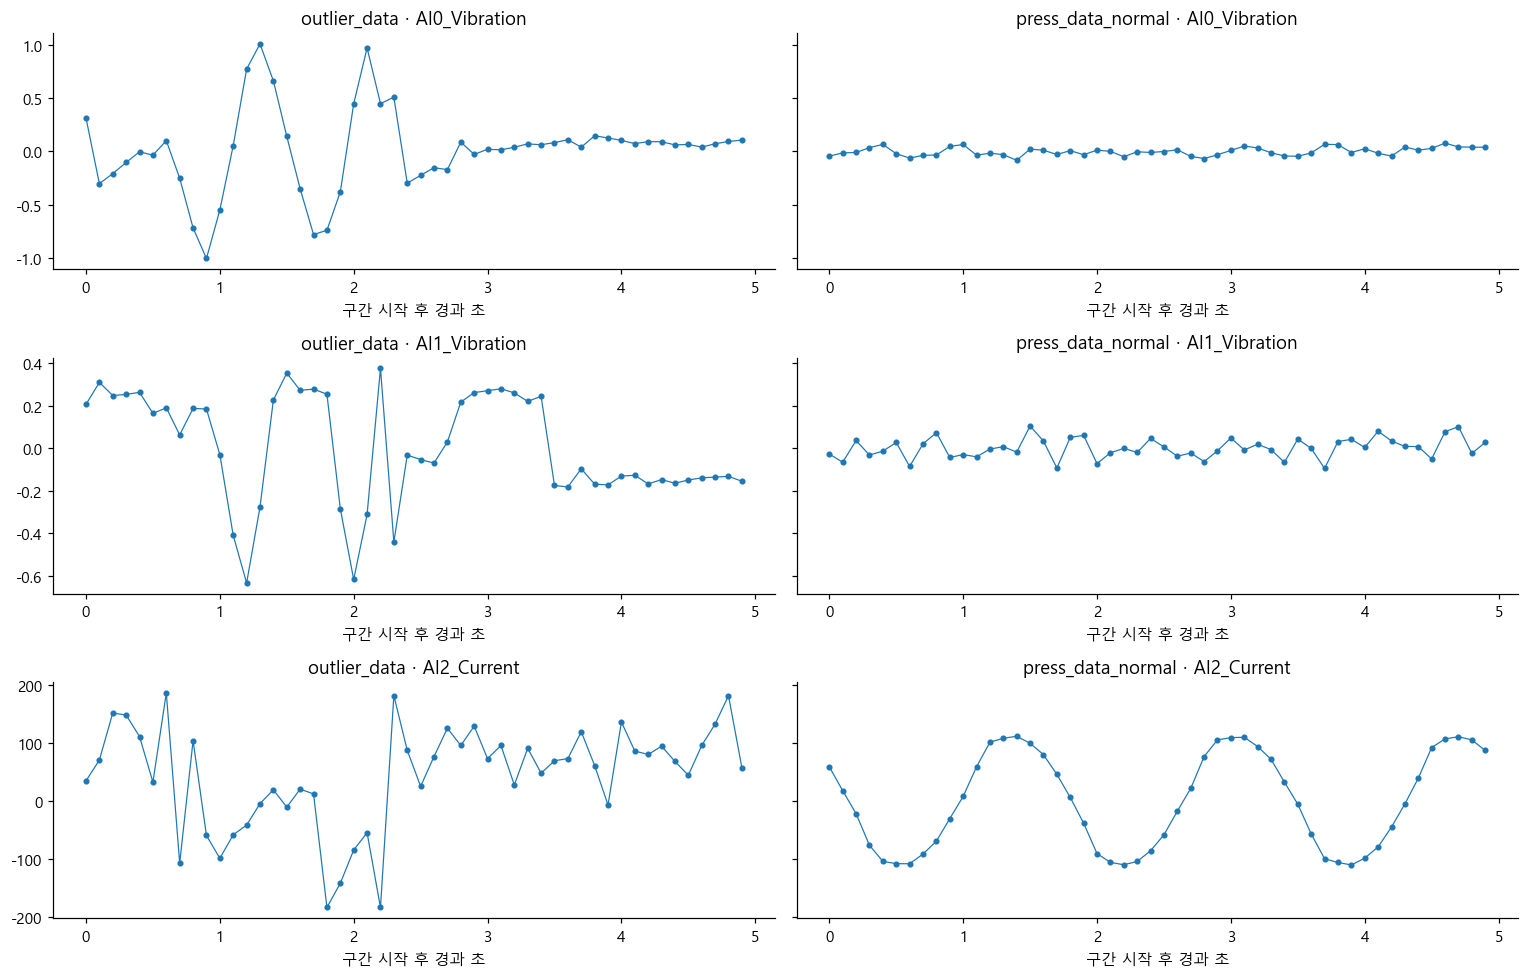

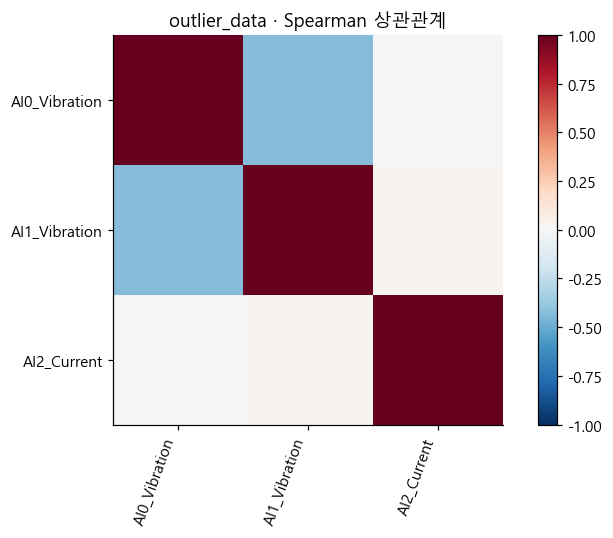

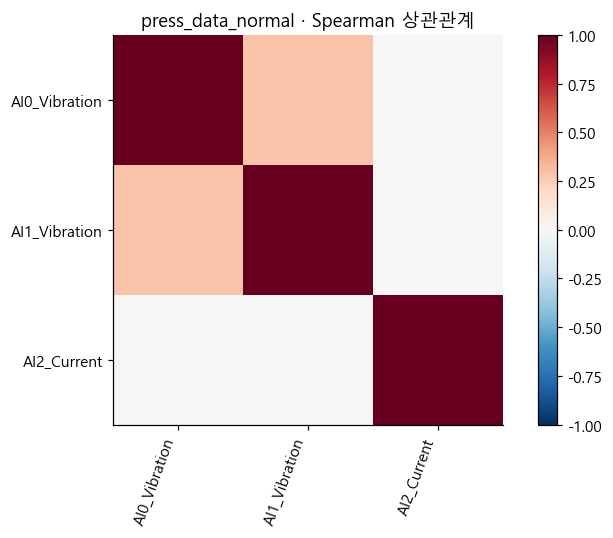

In [4]:
fig,axes=plt.subplots(1,3,figsize=(15,4))
for ax,c in zip(axes,sensors):
    bins=np.histogram_bin_edges(all_data[c].dropna(),bins=60)
    for name,df in frames.items():ax.hist(df[c].dropna(),bins=bins,density=True,histtype='step',label=name,linewidth=1.5)
    ax.set_title(c);ax.set_ylabel('밀도');ax.legend(fontsize=7)
plt.tight_layout();plt.show()
fig,axes=plt.subplots(3,2,figsize=(14,9),sharey='row')
for j,(name,df) in enumerate(frames.items()):
    segment=df.groupby('segment').size().idxmax(); sample=df[df.segment.eq(segment)].head(100)
    t=(sample.time-sample.time.iloc[0]).dt.total_seconds()
    for i,c in enumerate(sensors):
        axes[i,j].plot(t,sample[c],marker='.',lw=.8);axes[i,j].set_title(name+' · '+c);axes[i,j].set_xlabel('구간 시작 후 경과 초')
plt.tight_layout();plt.show()
for name,df in frames.items():corr_plot(df,sensors,name+' · Spearman 상관관계')

## 4. 연속 구간 내부의 1초 RMS
10개 표본이 연속인 창만 사용합니다. RMS는 진폭 크기의 요약이며 이상 정답을 새로 생성하지 않습니다. 겹치는 창은 서로 독립인 표본이 아니므로 무작위 분할하면 안 됩니다.

AI0_Vibration                               AI1_Vibration  \
                          count    median      mean       std         count   
source                                                                        
outlier_data                428  0.178534  0.331368  0.292434           428   
press_data_normal         14871  0.063666  0.065819  0.024792         14871   

                                                AI2_Current              \
                     median      mean       std       count      median   
source                                                                    
outlier_data       0.189149  0.207683  0.103548         428  103.203042   
press_data_normal  0.086768  0.103221  0.058814       14871  100.915145   

                                          
                         mean        std  
source                                    
outlier_data       131.406725  83.112663  
press_data_normal  117.076164  37.069013

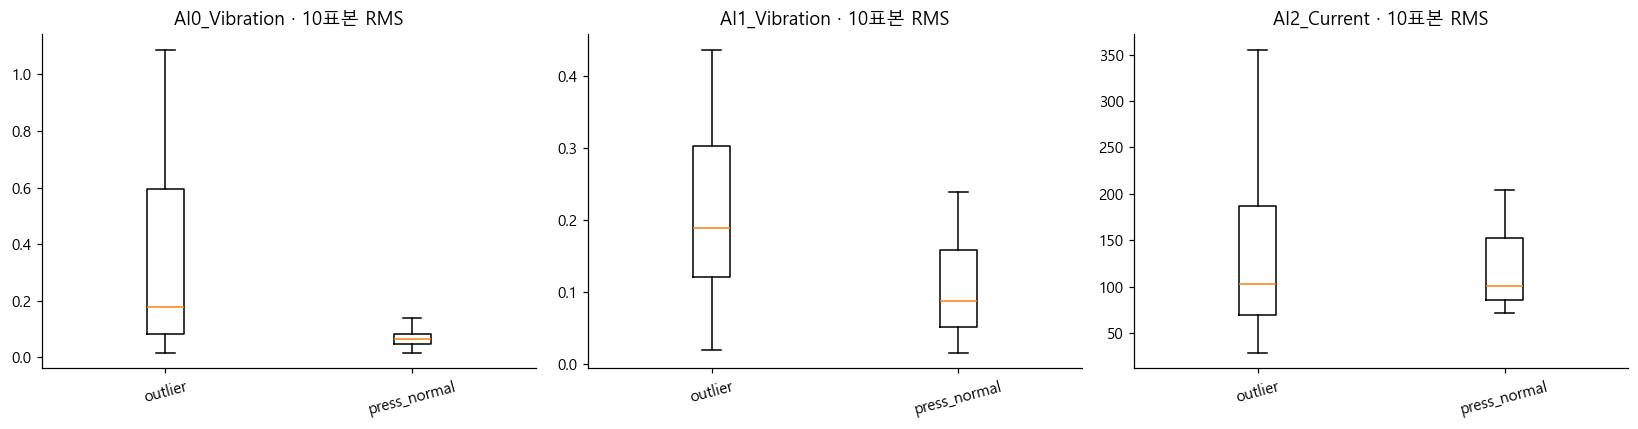

파일별 시간대:


,min,max
source,,
outlier_data,2022-07-17 10:51:07.943,2022-07-17 10:53:53.540
press_data_normal,2022-07-12 00:00:00.019,2022-07-12 01:16:55.828


In [5]:
rms_parts=[]
for (source,segment),g in all_data.groupby(['source','segment'],sort=False):
    rms=g[sensors].pow(2).rolling(10,min_periods=10).mean().pow(.5)
    rms['source']=source; rms['segment']=segment
    rms_parts.append(rms.dropna(subset=sensors))
rms=pd.concat(rms_parts,ignore_index=True)
display(rms.groupby('source')[sensors].agg(['count','median','mean','std']))
fig,axes=plt.subplots(1,3,figsize=(15,4))
for ax,c in zip(axes,sensors):
    groups=list(rms.groupby('source'))
    ax.boxplot([g[c] for _,g in groups],tick_labels=[name.replace('_data','') for name,_ in groups],showfliers=False)
    ax.set_title(c+' · 10표본 RMS');ax.tick_params(axis='x',rotation=15)
plt.tight_layout();plt.show()
print('파일별 시간대:');display(all_data.groupby('source').time.agg(['min','max']))

## 5. 주제 선정 해석
- 정상 20,000행과 이상 600행이 있으며, 표본 수보다 독립적인 수집 세션 수가 검증의 핵심입니다.
- 0.1초 연속성 기준으로 정상은 600구간, 이상은 21구간으로 나뉩니다. 구간은 독립 세션을 보장하지 않습니다. AI0 진동의 표준편차는 정상 약 0.071, 이상 약 0.448로 차이가 있지만 수집 조건 영향을 구분해야 합니다.
- 정상은 7월 12일, 이상은 7월 17일에 수집되었습니다. 상태 차이와 날짜/운전조건 차이가 섞일 수 있어 분포 차이를 고장 효과로 단정할 수 없습니다.
- 현재 데이터는 이상 상태 탐지의 출발점입니다. 고장 발생 시각, 고장 전후 연속 기록, 정비 이력이 없으므로 잔여수명이나 사전 고장 예측을 직접 검증하기 어렵습니다.
- 새 정상/이상 세션을 확보하고 세션 단위로 분할해야 합니다. 겹치는 창은 같은 분할에 두고, 정상 학습 데이터만으로 임계값을 추정합니다.
- 측정 공백을 제거한 것처럼 이어붙여 FFT를 계산하면 시간축이 왜곡되므로, 본 EDA에서는 연속 구간 파형과 RMS를 사용합니다.